# Step1: Data Gathering

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
path=r"https://raw.githubusercontent.com/ashwini-ah18/machin-larning-datasets/refs/heads/main/Classification%20Train%20dataset.csv"
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(path)
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


### 2. Check data shape, columns, and data types

In [3]:
print("Shape:", df.shape)

Shape: (136429, 14)


In [4]:
# Column names
print("\nColumns:\n", df.columns)



Columns:
 Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')


In [5]:
# Data types and null info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  str    
 2   Type                     136429 non-null  str    
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: float64(3), 

### 3. Identify target and feature columns

Assuming your target is Machine failure:

In [6]:
target = "Machine failure"

# Features = all columns except target
features = [col for col in df.columns if col != target]

print("Target column:", target)
print("Number of features:", len(features))
print(features)

Target column: Machine failure
Number of features: 13
['id', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [7]:
# Quick check of unique values in possible target column
df[target].unique()

array([0, 1])

### 4. Understand value counts of Machine failure (check imbalance)

In [8]:
# Count of each class
df[target].value_counts()

Machine failure
0    134281
1      2148
Name: count, dtype: int64

***Percentage distribution (important for imbalance check)***

In [9]:
df[target].value_counts(normalize=True) * 100

Machine failure
0    98.425555
1     1.574445
Name: proportion, dtype: float64

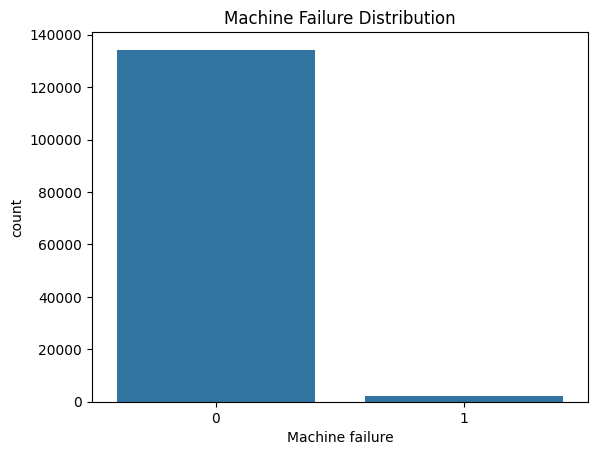

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=df[target])
plt.title("Machine Failure Distribution")
plt.show()

# 2. Data Cleaning

In [11]:
##1) Check for missing values
# Check missing values per column
print(df.isnull().sum())

id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [12]:
# Drop rows with missing values
df = df.dropna()

In [13]:
###2) Handle duplicates
# Check duplicates
print(df.duplicated().sum())


0


In [14]:
# View duplicate rows (optional)
print(df[df.duplicated()])


Empty DataFrame
Columns: [id, Product ID, Type, Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min], Machine failure, TWF, HDF, PWF, OSF, RNF]
Index: []


In [15]:
# View duplicate rows (optional)
print(df[df.duplicated()])


Empty DataFrame
Columns: [id, Product ID, Type, Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min], Machine failure, TWF, HDF, PWF, OSF, RNF]
Index: []


In [16]:
# Check data types
print(df.dtypes)


id                           int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [17]:
###Verify and encode categorical column (Type)
print(df["Type"].unique())
print(df["Type"].value_counts())

<StringArray>
['L', 'M', 'H']
Length: 3, dtype: str
Type
L    95354
M    32152
H     8923
Name: count, dtype: int64


In [18]:
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

In [19]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  str    
 2   Air temperature [K]      136429 non-null  float64
 3   Process temperature [K]  136429 non-null  float64
 4   Rotational speed [rpm]   136429 non-null  int64  
 5   Torque [Nm]              136429 non-null  float64
 6   Tool wear [min]          136429 non-null  int64  
 7   Machine failure          136429 non-null  int64  
 8   TWF                      136429 non-null  int64  
 9   HDF                      136429 non-null  int64  
 10  PWF                      136429 non-null  int64  
 11  OSF                      136429 non-null  int64  
 12  RNF                      136429 non-null  int64  
 13  Type_L                   136429 non-null  bool   
 14  Type_M         

In [20]:
print(df.isnull().sum())

id                         0
Product ID                 0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
Type_L                     0
Type_M                     0
dtype: int64


## Histograms (Temperature, Speed, Torque)

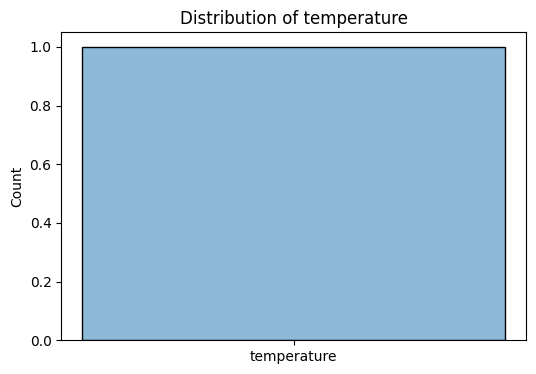

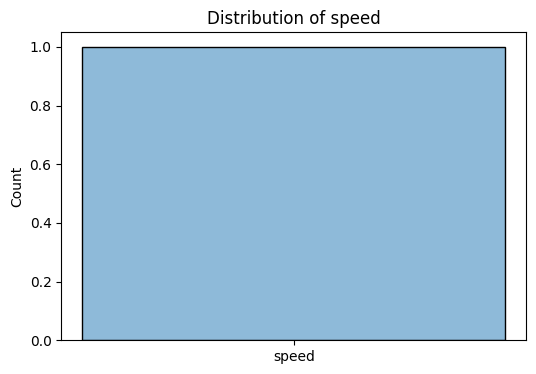

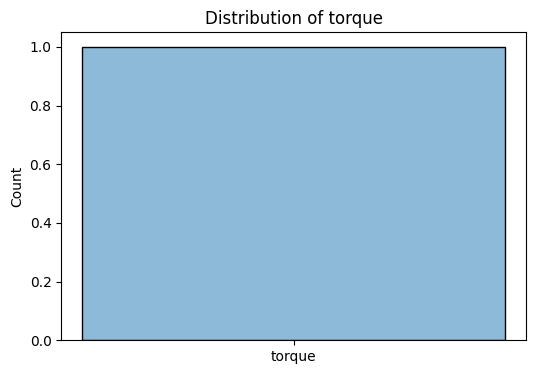

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['temperature', 'speed', 'torque']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.histplot([feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.show()

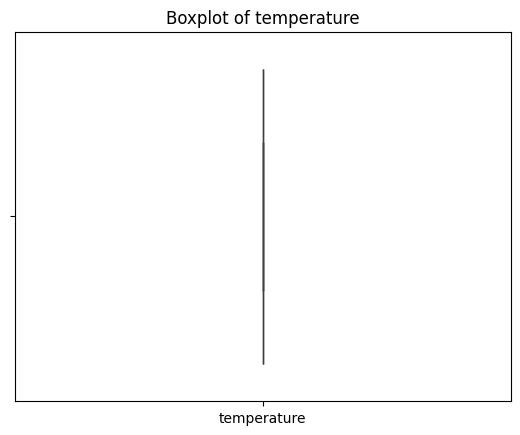

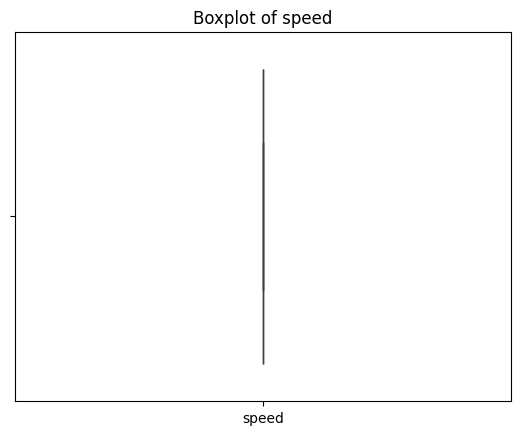

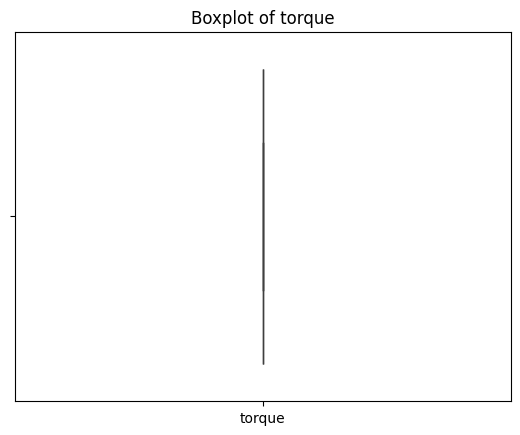

In [22]:
for feature in features:
    plt.figure()
    sns.boxplot(x=[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

In [23]:
df = df.drop(columns=['UDI', 'Product ID'], errors='ignore')
df.select_dtypes(include=['object']).columns

Index([], dtype='str')

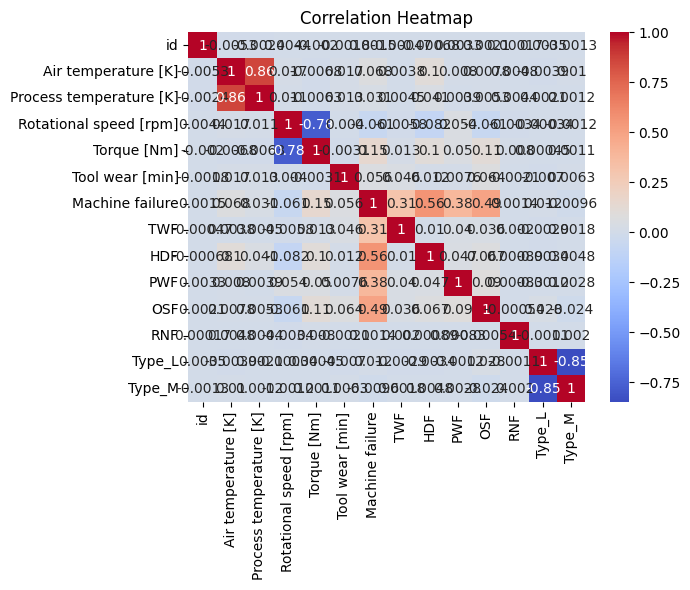

In [24]:
cor_matrix = df.corr()
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


### Compare Failed vs Non-Failed Machines

In [25]:
df.rename(columns={"Machine failure": "Failure"}, inplace=True)

In [26]:
print(df["Failure"].value_counts())


Failure
0    134281
1      2148
Name: count, dtype: int64


In [27]:
features = ["Air temperature [K]", "Process temperature [K]", 
            "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

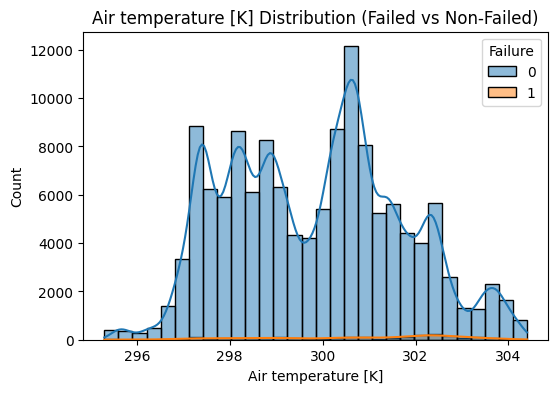

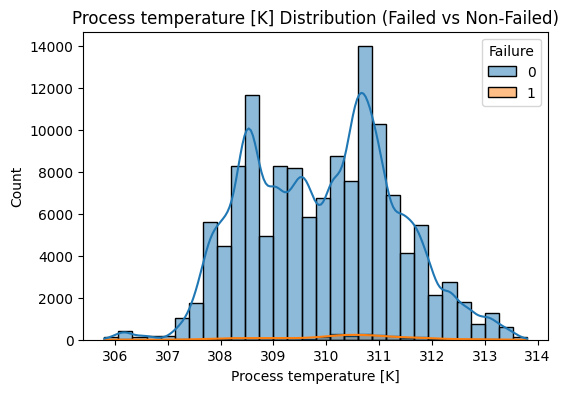

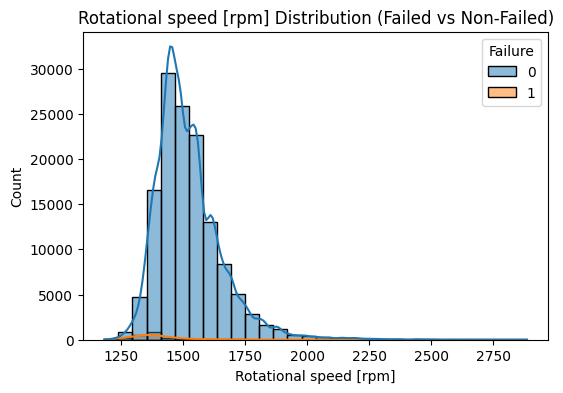

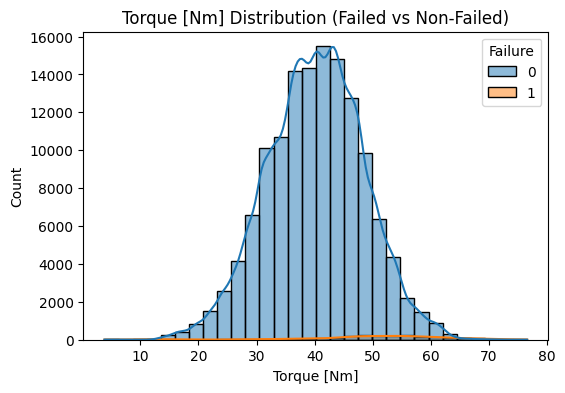

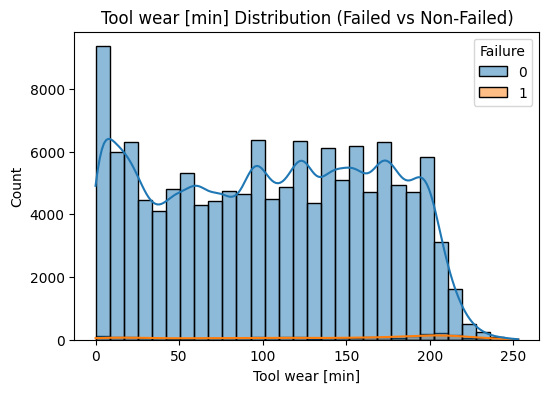

In [28]:
for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="Failure", kde=True, bins=30)
    plt.title(f"{col} Distribution (Failed vs Non-Failed)")
    plt.show()